# M2 — The Analytic Inelastic Terms: `f_phys`, `K_fl`, and the Composition Law

**Inelastic coding prompt 3, task 4** (2026-08-24). M2 ported the *fixed* BING
inelastic physics to pure JAX — `robust.rt.inelastic.raman_factor` (the
multiplicative Raman correction) and `fluorescence_kernel` (the additive,
φ_C-linear chlorophyll term) — and composed them into `robust.rt.forward`.
The code gate is green (task 3): both terms pin to live BING at
rtol ≤ 1e-6 (measured 4e-16 / 1e-13 in float64), the assessment's error table
is reproduced on the CI fixture and pinned as bands, and `jax.grad` matches
central finite differences for every input including the two new handles,
`a_ph` and `φ_C`.

This notebook is the *picture* of that state: what the analytic backbone
already gets right, and — deliberately — the structured residuals that M3's
learned heads (δ_R, δ_F) exist to close. Every number shown here is
test-pinned; nothing is re-derived.


In [1]:
import sys
from pathlib import Path

# notebooks/RT/ -> repo root on sys.path (robust is not pip-installed here).
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp
import numpy as np

from robust.rt import hybrid as H
from robust.rt import inelastic as I
from robust.rt.data import l23 as L
from robust.rt.types import Inelastic
from robust.tests.conftest import L23_INELASTIC_FIXTURE, L23_SMALL_FIXTURE

batch = L.load_inelastic_batch(
    reader=L.inelastic_npz_reader(L23_INELASTIC_FIXTURE, L23_SMALL_FIXTURE))
wave = np.asarray(batch.wave)
i685 = int(np.abs(wave - 685).argmin())

# The two analytic terms, once, for the whole fixture (150 = 50 scenes x 3 zeniths).
f_phys = np.asarray(I.raman_factor(batch.iops, batch.geometry, batch.wave))
k_fl = np.asarray(I.fluorescence_kernel(batch.iops, batch.geometry, batch.wave))
fl_model = L.PHI_C_L23 * k_fl

raman_truth = np.asarray(batch.truth_raman_factor)      # Rrs_X2 / Rrs_X1
fl_truth = np.asarray(batch.truth_fluorescence)         # Rrs_X4 - Rrs_X2

print(f'repo: {REPO}')
print(f'jax {jax.__version__} on {jax.default_backend()}')
print(f'fixture: {f_phys.shape[0]} samples x {f_phys.shape[1]} wavelengths')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


repo: /mnt/tank/Oceanography/python/retrieve-or-bust
jax 0.11.1 on cpu
fixture: 150 samples x 81 wavelengths


## 1. The composition law — and why one term multiplies while the other adds

The design (§2) composes the inelastic processes onto the elastic hybrid in
`Rrs` space:

$$R_{rs}^{\mathrm{total}}(\lambda) \;=\; \underbrace{\bigl(R_{rs}^{\mathrm{ZTT}} + \Delta R_{rs}\bigr)}_{\text{elastic hybrid}} \times \underbrace{f_R(\lambda)}_{\text{Raman}} \;+\; \underbrace{\phi_C \, K_{fl}(\lambda)}_{\text{fluorescence}}$$

with `f_R = f_phys` and no δ heads until M3. The asymmetry is physics, not
convention:

- **Raman scattering is a property of the water itself.** Every photon field
  in the ocean is Raman-shifted by the same medium, so the effect scales
  *with* the elastic field around it — a **ratio**
  `f_phys = (R_E + R_Raman)/R_E`. The ratio form is also *self-normalizing*:
  two-flow normalization errors largely cancel between numerator and
  denominator, which is why BING's Raman was about right all along while its
  pre-fix fluorescence — where nothing divides out — was ×3 too bright until
  the `L_u = E_u/\pi` fix.
- **Fluorescence is a source term.** Phytoplankton absorb blue-green photons
  (`b_F = φ_C · a_ph(λ')`) and re-emit them isotropically in a 685 nm line
  that the elastic field does not contain at all. New photons **add**; and
  because the source is linear in the quantum yield, the term is written
  `φ_C · K_fl` with the kernel independent of φ_C — making the yield a clean,
  differentiable retrieval handle (§4 below) instead of a baked-in constant.

The `inelastic=None` route bypasses all of this untouched — the elastic hash
pins have stayed bit-identical through every M2 task.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- house style (elastic notebook 1) ---
INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
BLUES = {0.0: '#9ecae1', 30.0: '#4292c6', 60.0: '#08519c'}
ORANGE = '#D55E00'
mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10.5,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# The composition, verified in one line on the fixture: forward(default) is
# forward(raman-only) plus the additive term, to float32 round-trip noise.
args = (batch.iops, batch.phase_params, batch.geometry, batch.wave)
full = np.asarray(H.forward(*args, inelastic=Inelastic(), check_domain=False))
raman_only = np.asarray(
    H.forward(*args, inelastic=Inelastic(fluorescence=False), check_domain=False))
residual = np.abs(full - (raman_only + fl_model)) / full.max()
print('composition law on the fixture: max |forward(default) - '
      f'(forward(raman-only) + phi_C*K_fl)| / max(Rrs) = {residual.max():.2e}')

composition law on the fixture: max |forward(default) - (forward(raman-only) + phi_C*K_fl)| / max(Rrs) = 6.31e-09


## 2. Raman: `f_phys` against the L23 truth — right at 30–60°, −39 % at 0°

Per zenith, the median spectrum of the modeled factor against the truth
`Rrs_X2/Rrs_X1`. At θ_s = 30° and 60° the two-flow assembly with the true
`Ed(λ')/Ed(λ)` ratio tracks the truth closely (median *increment* error
+1.6 % / −4.0 % over 550–700 nm). At 0° it undershoots the increment by
**−38.6 %** — S&P98's fixed mean cosines (μ_d = 0.9) are wrong for an
overhead sun — and on the blue side the model *overshoots* by ~+30 % at
490 nm (30–60°). Both residuals are smooth in (θ_s, λ): exactly the shape a
small learned δ_R can close, and the M3 gate demands |error| ≤ 5 % at every
zenith including 0°.


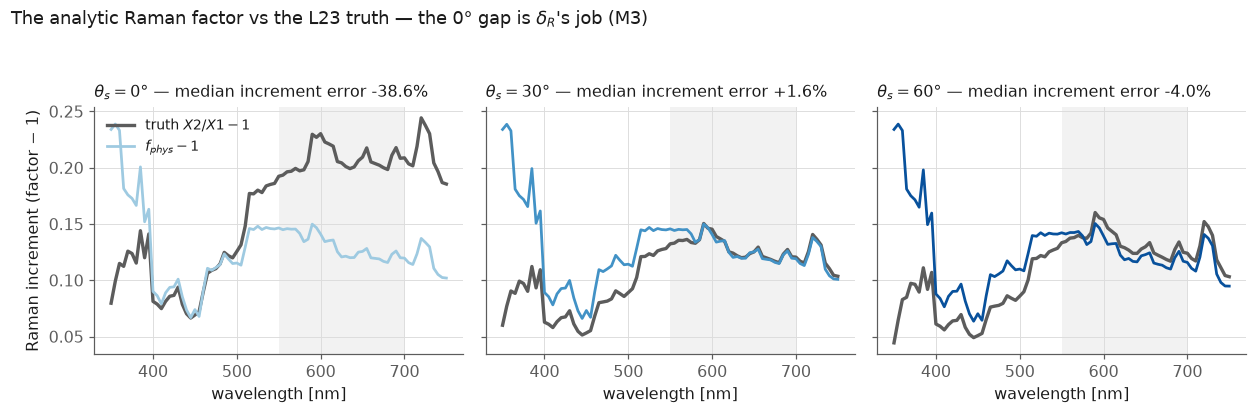

the pinned error table on this fixture (median increment error):
  theta_s= 0°:  550-700 nm  -38.6%   490 nm   -3.0%
  theta_s=30°:  550-700 nm   +1.6%   490 nm  +29.7%
  theta_s=60°:  550-700 nm   -4.0%   490 nm  +30.3%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)
for ax, (theta, color) in zip(axes, BLUES.items()):
    rows = batch.zenith == theta
    med_model = np.median(f_phys[rows] - 1.0, axis=0)
    med_truth = np.median(raman_truth[rows] - 1.0, axis=0)
    ax.plot(wave, med_truth, color=INK_MUTED, lw=2.2, label='truth $X2/X1 - 1$')
    ax.plot(wave, med_model, color=color, lw=1.8, label='$f_{phys} - 1$')
    ax.axvspan(550, 700, color=GRID, alpha=0.35, lw=0)
    err = np.median((f_phys[rows][:, (wave >= 550) & (wave <= 700)] - 1.0)
                    / (raman_truth[rows][:, (wave >= 550) & (wave <= 700)] - 1.0)) - 1.0
    ax.set_title(f'$\\theta_s = {theta:.0f}°$ — median increment error '
                 f'{100 * err:+.1f}%', fontsize=10.5, loc='left')
    ax.set_xlabel('wavelength [nm]')
axes[0].set_ylabel('Raman increment (factor $-$ 1)')
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle('The analytic Raman factor vs the L23 truth — the 0° gap is '
             '$\\delta_R$\'s job (M3)', x=0.01, ha='left', fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

i490 = int(np.abs(wave - 490).argmin())
print('the pinned error table on this fixture (median increment error):')
for theta in (0.0, 30.0, 60.0):
    rows = batch.zenith == theta
    band = (wave >= 550) & (wave <= 700)
    e_band = np.median((f_phys[rows][:, band] - 1) / (raman_truth[rows][:, band] - 1)) - 1
    e_490 = np.median((f_phys[rows, i490] - 1) / (raman_truth[rows, i490] - 1)) - 1
    print(f'  theta_s={theta:2.0f}°:  550-700 nm {100 * e_band:+6.1f}%   '
          f'490 nm {100 * e_490:+6.1f}%')

## 3. Fluorescence: `φ_C · K_fl` against the truth — amplitude right, drift visible

Three trophic states (by `a_ph(440)` percentile, θ_s = 30°): the kernel at the
truth's φ_C = 0.02 lands on the `Rrs_X4 − Rrs_X2` line in both shape and
amplitude — this is the term that was ×3 wrong before the π fix. What remains
is a *drift*: the median 685 nm model/truth ratio is **0.99 / 0.94 / 0.85**
at 0/30/60° on this fixture (the assessment's 1.00/0.95/0.86), and it slides
with trophic state — the two-flow attenuation treats the emission column too
crudely as the water darkens or the sun drops. Smooth in
(θ_s, `a_ph`): δ_F's target, gated at ≤ 5 % in M3.


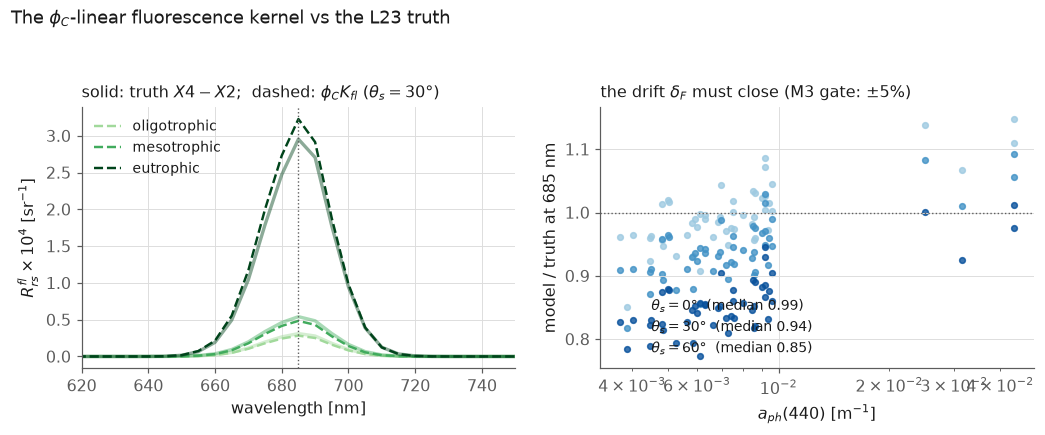

In [4]:
at30 = np.flatnonzero(batch.zenith == 30.0)
aph440 = np.asarray(batch.iops.a_ph)[at30, np.abs(wave - 440).argmin()]
order = at30[np.argsort(aph440)]
picks = {'oligotrophic': order[0], 'mesotrophic': order[len(order) // 2],
         'eutrophic': order[-1]}
GREENS = dict(zip(picks, ['#a1d99b', '#41ab5d', '#00441b']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.0))
for (label, i), color in zip(picks.items(), GREENS.values()):
    ax1.plot(wave, 1e4 * fl_truth[i], color=color, lw=2.2, alpha=0.45)
    ax1.plot(wave, 1e4 * fl_model[i], color=color, lw=1.6, ls='--',
             label=label)
ax1.set_xlim(620, 750)
ax1.axvline(685, color=INK_MUTED, lw=0.9, ls=':')
ax1.set_xlabel('wavelength [nm]')
ax1.set_ylabel(r'$R_{rs}^{fl} \times 10^4$ [sr$^{-1}$]')
ax1.set_title('solid: truth $X4-X2$;  dashed: $\\phi_C K_{fl}$ '
              '($\\theta_s = 30°$)', fontsize=10.5, loc='left')
ax1.legend(loc='upper left', fontsize=9)

for theta, color in BLUES.items():
    rows = batch.zenith == theta
    ratio = fl_model[rows, i685] / fl_truth[rows, i685]
    aph = np.asarray(batch.iops.a_ph)[rows, np.abs(wave - 440).argmin()]
    ax2.scatter(aph, ratio, s=14, color=color, alpha=0.8,
                label=f'$\\theta_s = {theta:.0f}°$  '
                      f'(median {np.median(ratio):.2f})')
ax2.axhline(1.0, color=INK_MUTED, lw=0.9, ls=':')
ax2.set_xscale('log')
ax2.set_xlabel(r'$a_{ph}(440)$ [m$^{-1}$]')
ax2.set_ylabel('model / truth at 685 nm')
ax2.set_title('the drift $\\delta_F$ must close (M3 gate: $\\pm$5%)',
              fontsize=10.5, loc='left')
ax2.legend(loc='lower left', fontsize=9)
fig.suptitle('The $\\phi_C$-linear fluorescence kernel vs the L23 truth',
             x=0.01, ha='left', fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 4. The new physiology handle: `∂Rrs/∂φ_C = K_fl`

Because the composed `Rrs` is *affine* in the quantum yield, its gradient is
the kernel itself — independent of φ_C, concentrated in the 685 nm line, and
larger the more phytoplankton there is to fluoresce. This is what the future
inversion differentiates to retrieve φ_C (Maritorena's ~1–6 % natural range;
Behrenfeld's NPQ signal) instead of assuming 0.02 forever. The identity is
also a live check on the plumbing: below, `jax.jacrev` of the full composed
`forward` through the emulator, the Raman factor, and both `Rrs`-space
conversions reproduces `K_fl` to float precision.


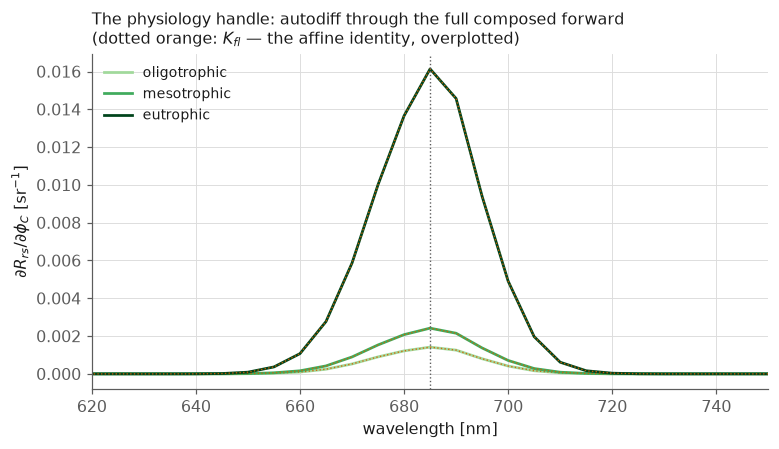

max |jacrev - K_fl| / max(K_fl) over the three scenes: 1.93e-07


In [5]:
rows3 = jax.tree_util.tree_map  # alias for brevity
grads = {}
for label, i in picks.items():
    iops_i = rows3(lambda x: x[i:i + 1], batch.iops)
    pp_i = rows3(lambda x: x[i:i + 1], batch.phase_params)
    geom_i = rows3(lambda x: x[i:i + 1], batch.geometry)

    def rrs_of_phi(phi, iops_i=iops_i, pp_i=pp_i, geom_i=geom_i):
        return H.forward(iops_i, pp_i, geom_i, batch.wave, 'hybrid',
                         inelastic=Inelastic(phi_C=phi), check_domain=False)[0]

    grads[label] = np.asarray(jax.jacrev(rrs_of_phi)(jnp.asarray(L.PHI_C_L23)))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for (label, i), color in zip(picks.items(), GREENS.values()):
    ax.plot(wave, grads[label], color=color, lw=1.8, label=label)
    ax.plot(wave, k_fl[i], color=ORANGE, lw=0.9, ls=':', alpha=0.9)
ax.set_xlim(620, 750)
ax.axvline(685, color=INK_MUTED, lw=0.9, ls=':')
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel(r'$\partial R_{rs} / \partial \phi_C$ [sr$^{-1}$]')
ax.set_title('The physiology handle: autodiff through the full composed '
             'forward\n(dotted orange: $K_{fl}$ — the affine identity, '
             'overplotted)', fontsize=10.5, loc='left')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

worst = max(np.abs(grads[label] - k_fl[i]).max()
            / max(k_fl[i].max(), 1e-30) for label, i in picks.items())
print(f'max |jacrev - K_fl| / max(K_fl) over the three scenes: {worst:.2e}')

## 5. Where this leaves us

The analytic backbone is now the *measured* starting point the design asked
for: exactly BING's fixed physics (pinned live at rtol ≤ 1e-6, sentinel-guarded
against a rolled-back checkout), exactly characterized against L23
(550–700 nm, 490 nm, and 685 nm bands all fixture-pinned), and differentiable
in every input the inversion will want — `a`, `bb_p`, `a_ph`, `θ_s`, and now
`φ_C` (verified against central finite differences; note the one-sided
θ_s-derivative at the Ed anchors 0/30/60°, record §4.4).

**M3 inherits three numbers to beat, all visible above:** the −39 % Raman
increment at 0°, the +30 % Raman overshoot at 490 nm, and the 0.99→0.85
fluorescence drift with zenith/trophic state — each smooth in its inputs,
each gated at ≤ 5 % for the learned heads
(`f_R = 1 + (f_phys − 1)(1 + δ_R)`; `Rrs_fl = φ_C · K_fl · (1 + δ_F)`).
